In [38]:
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
)

In [ ]:
# === specify the exact model paths to be evaluated ===
model_paths = {
    "Stability Selection": "../models/lasso_stability_selection_grid_search/lasso_model.joblib",
    "SelectKBest": "../models/lasso_selectkbest_grid_search/lasso_model.joblib",
    "Bootstrapped SelectKBest": "../models/lasso_bootstrapped_selectkbest_grid_search/lasso_model.joblib",
    "Lasso no feature selection": "../models/lasso_no_feature_selection/lasso_model.joblib",
    "RandomForest SelectKBest": "../models/randomforest_selectkbest_grid_search/rf_model.joblib",
    "XGBoost SelectKBest": "../models/xgboost_selectkbest_grid_search/xgb_model.joblib"
}


# === Directories for data and preprocessing ===
DATA_DIR = "../split_data"

# === Load data ===
print("Loading split data...")
X_val = joblib.load(os.path.join(DATA_DIR, "X_val.joblib"))
y_val = joblib.load(os.path.join(DATA_DIR, "y_val.joblib"))

# === Evaluate models ===
results = []

for model_name, model_path in model_paths.items():
    if not os.path.exists(model_path):
        print(f"⚠️ Skipping missing model: {model_path}")
        continue

    print(f"\nEvaluating {model_path}...")
    model = joblib.load(model_path)

    # Get predictions
    y_prob = model.predict_proba(X_val)[:, 1]
    y_pred = model.predict(X_val)

    # Compute metrics
    auc = roc_auc_score(y_val, y_prob)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    acc = accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    results.append({
        "Model": model_name,
        "Path": model_path,
        "AUROC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Accuracy": acc,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
    })

# === Display results ===
results_df = pd.DataFrame(results).sort_values(by="AUROC", ascending=False)

print("\nModel Performance Comparison:\n")
print(results_df.to_string(index=False, float_format="%.4f"))

# Save results
# results_df.to_csv("model_comparison_selected.csv", index=False)
# print("\nResults saved to model_comparison_selected.csv")


Loading split data...

Evaluating ../models/lasso_stability_selection_grid_search/lasso_model.joblib...
dropping 3243 columns total from mrna
dropping 1462 columns total from mutation data
dropping 3243 columns total from mrna
dropping 1462 columns total from mutation data

Evaluating ../models/lasso_selectkbest_grid_search/lasso_model.joblib...
dropping 3243 columns total from mrna
dropping 1462 columns total from mutation data
dropping 3243 columns total from mrna
dropping 1462 columns total from mutation data

Evaluating ../models/lasso_bootstrapped_selectkbest_grid_search/lasso_model.joblib...
dropping 3243 columns total from mrna
dropping 1462 columns total from mutation data
dropping 3243 columns total from mrna
dropping 1462 columns total from mutation data

Evaluating ../models/lasso_no_feature_selection/lasso_model.joblib...
dropping 3181 columns total from mrna
dropping 1462 columns total from mutation data
dropping 3181 columns total from mrna
dropping 1462 columns total fro

dropping 3243 columns total from mrna
dropping 1462 columns total from mutation data
dropping 3243 columns total from mrna
dropping 1462 columns total from mutation data
dropping 3243 columns total from mrna
dropping 1462 columns total from mutation data
dropping 3181 columns total from mrna
dropping 1462 columns total from mutation data
dropping 3181 columns total from mrna
dropping 1462 columns total from mutation data


KeyboardInterrupt: 

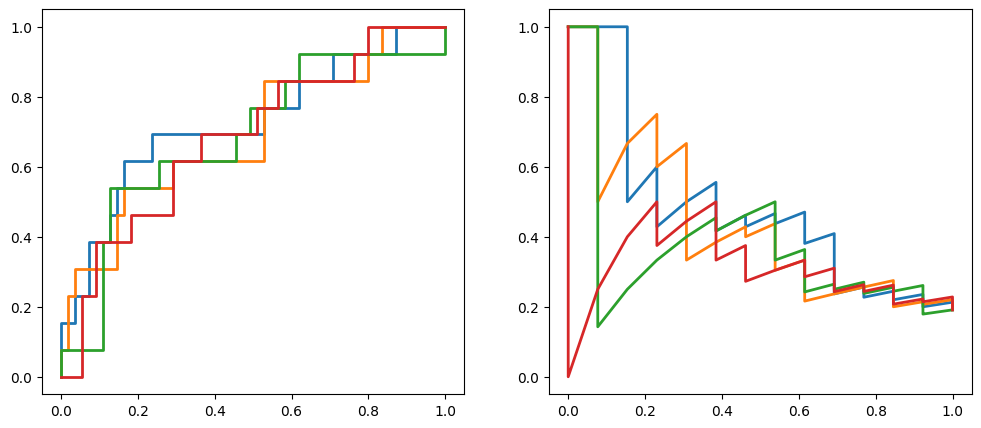

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import joblib


# Initialize plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC and PR plots
for label, path in model_paths.items():
    model = joblib.load(path)
    y_proba = model.predict_proba(X_val)[:, 1]
    
    # ROC
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, label=f"{label} (AUC = {roc_auc:.2f})")

    # Precision–Recall
    precision, recall, _ = precision_recall_curve(y_val, y_proba)
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, lw=2, label=f"{label} (AUC = {pr_auc:.2f})")

# ROC formatting
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curves", fontsize=14)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Sensitivity)")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# PR formatting
axes[1].set_title("Precision–Recall Curves", fontsize=14)
axes[1].set_xlabel("Recall (Sensitivity)")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
nonzero_counts = {}

for name, path in model_paths.items():
    model = joblib.load(path)
    clf = model.named_steps["clf"]  # your logistic regression or similar
    coefs = clf.coef_.ravel()
    print(len(coefs))
    nonzero_counts[name] = np.sum(coefs != 0)

for name, count in nonzero_counts.items():
    print(f"{name}: {count} non-zero coefficients")


45
50
50
35031
Stability Selection: 45 non-zero coefficients
SelectKBest: 42 non-zero coefficients
Bootstrapped SelectKBest: 45 non-zero coefficients
Lasso no feature selection: 34825 non-zero coefficients


In [ ]:
import numpy as np
import pandas as pd
import joblib

def get_feature_info(model):
    """Return nonzero features, their names, and weights for a sklearn pipeline."""
    # Core components
    steps = model.named_steps
    pre = steps.get("preprocessor")
    clf = steps["clf"]

    # Step 1: Get initial feature names
    feature_names = np.array(pre.get_feature_names_out())

    # Step 2: Apply variance threshold if it exists
    if "var_thresh" in steps and hasattr(steps["var_thresh"], "get_support"):
        var_mask = steps["var_thresh"].get_support()
        feature_names = feature_names[var_mask]

    # Step 3: Apply feature selector if it exists
    if "select" in steps:
        select = steps["select"]
        if hasattr(select, "get_support"):
            select_mask = select.get_support()
            feature_names = feature_names[select_mask]
        else:
            # Fallback for selectors without get_support (e.g., StabilitySelection)
            feature_names = feature_names[:clf.coef_.shape[1]]

    # Step 4: Extract coefficients
    coefs = clf.coef_.ravel()

    # Step 5: Filter nonzero coefficients
    nonzero_mask = coefs != 0
    nonzero_features = feature_names[nonzero_mask]
    nonzero_coefs = coefs[nonzero_mask]

    # Step 6: Create dataframe
    df = pd.DataFrame({
        "feature": nonzero_features,
        "weight": nonzero_coefs
    }).sort_values("weight", key=abs, ascending=False)

    return df, len(nonzero_features)

feature_dfs = {}

for name, path in model_paths.items():
    model = joblib.load(path)
    df, count = get_feature_info(model)
    feature_dfs[name] = df
    print(f"{name}: {count} nonzero features")
    print(df.head(20))
    print()

Stability Selection: 45 nonzero features
                   feature    weight
43      mutation__SOX9_mut -5.312203
36   mutation__ERBB2IP_mut -3.996317
40       mutation__RLF_mut -3.679554
42  mutation__SMARCAD1_mut -3.315776
37     mutation__IGF2R_mut -2.988948
41    mutation__RNF213_mut -2.712752
39      mutation__MUC4_mut -1.843063
38     mutation__MED23_mut -1.262407
44     mutation__WDR87_mut -1.248082
3               mrna__ASB9  1.057681
29              mrna__TCP1  1.024350
6           mrna__C9orf103 -0.860014
25           mrna__SLC47A1  0.741029
34            mrna__ZNF446  0.720069
18             mrna__PCMT1 -0.690721
1            mrna__ARFGAP3 -0.677453
17             mrna__PARVG  0.648968
21           mrna__PPP2R2C -0.571026
30            mrna__TMEM91 -0.558738
5            mrna__C1orf64  0.543049

SelectKBest: 42 nonzero features
               feature    weight
40  mutation__MUC4_mut -1.786710
27         mrna__SMYD4 -1.063544
6       mrna__C9orf103 -0.789195
2           mrna

In [ ]:
# Get sets of features
sets = {name: set(df["feature"]) for name, df in feature_dfs.items()}

# Pairwise intersections
for name1, s1 in sets.items():
    for name2, s2 in sets.items():
        if name1 < name2:
            overlap = len(s1 & s2)
            print(f"{name1} & {name2}: {overlap} shared features")

# Get sets of features
sets = {name: set(df["feature"]) for name, df in feature_dfs.items()}

# Pairwise intersections (with feature names)
for name1, s1 in sets.items():
    for name2, s2 in sets.items():
        if name1 < name2:  # to avoid duplicates
            overlap = s1 & s2
            print(f"\n{name1} & {name2}: {len(overlap)} shared features")
            if overlap:
                print(", ".join(sorted(overlap)))
            else:
                print("(No shared features)")



SelectKBest & Stability Selection: 29 shared features
Bootstrapped SelectKBest & Stability Selection: 21 shared features
Bootstrapped SelectKBest & SelectKBest: 24 shared features
Bootstrapped SelectKBest & Lasso no feature selection: 45 shared features
Lasso no feature selection & Stability Selection: 45 shared features
Lasso no feature selection & SelectKBest: 42 shared features

SelectKBest & Stability Selection: 29 shared features
mrna__ADAMTS8, mrna__ARFGAP3, mrna__ASB2, mrna__ASB9, mrna__C1orf64, mrna__C9orf103, mrna__CSE1L, mrna__CYB5D2, mrna__EFCAB6, mrna__HSPD1, mrna__LRRN4CL, mrna__NAA50, mrna__PARVG, mrna__PCMT1, mrna__PHLDA3, mrna__PHYHD1, mrna__PPP2R2C, mrna__PRKDC, mrna__SLC25A35, mrna__SMG6, mrna__STIP1, mrna__TBC1D2, mrna__TCP1, mrna__TMEM91, mrna__VPS39, mrna__XPO5, mrna__ZNF446, mrna__ZNF79, mutation__MUC4_mut

Bootstrapped SelectKBest & Stability Selection: 21 shared features
mrna__ADAMTS8, mrna__ASB9, mrna__C17orf68, mrna__C9orf103, mrna__CIRBP, mrna__CSE1L, mrna__C

In [ ]:
import numpy as np
import pandas as pd

# Assume you already have your models stored like this


# Find shared across all models
shared_all = set.intersection(*(set(df["feature"]) for df in feature_dfs.values()))
print(f"Shared across ALL models: {len(shared_all)}")
print(shared_all)

# Optional: pairwise overlaps
model_names = list(feature_dfs.keys())
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        m1, m2 = model_names[i], model_names[j]
        overlap = set(feature_dfs[m1]["feature"]) & set(feature_dfs[m2]["feature"])
        print(f"Shared between {m1} and {m2}: {len(overlap)}")



Shared across ALL models: 17
{'mrna__ZNF446', 'mrna__PHYHD1', 'mrna__PPP2R2C', 'mrna__VPS39', 'mrna__ASB9', 'mrna__CSE1L', 'mrna__SMG6', 'mrna__PHLDA3', 'mrna__CYB5D2', 'mrna__NAA50', 'mrna__ADAMTS8', 'mrna__SLC25A35', 'mrna__TMEM91', 'mrna__ZNF79', 'mrna__HSPD1', 'mrna__XPO5', 'mrna__C9orf103'}
Shared between Stability Selection and SelectKBest: 29
Shared between Stability Selection and Bootstrapped SelectKBest: 21
Shared between Stability Selection and Lasso no feature selection: 45
Shared between SelectKBest and Bootstrapped SelectKBest: 24
Shared between SelectKBest and Lasso no feature selection: 42
Shared between Bootstrapped SelectKBest and Lasso no feature selection: 45

Stability Selection selected 45 features


,feature,weight
43,mutation__SOX9_mut,-5.312203
36,mutation__ERBB2IP_mut,-3.996317
40,mutation__RLF_mut,-3.679554
42,mutation__SMARCAD1_mut,-3.315776
37,mutation__IGF2R_mut,-2.988948



SelectKBest selected 42 features


,feature,weight
40,mutation__MUC4_mut,-1.786710
27,mrna__SMYD4,-1.063544
6,mrna__C9orf103,-0.789195
2,mrna__ASB2,-0.733530
39,mrna__ZNF853,-0.693163



Bootstrapped SelectKBest selected 45 features


,feature,weight
33,mrna__SMYD4,-0.960909
4,mrna__C9orf103,0.739577
13,mrna__GALNT12,0.660376
10,mrna__CYB5D2,0.637419
38,mrna__UVRAG,-0.601507



Lasso no feature selection selected 34825 features


,feature,weight
1,clinical__AJCC_STAGING_EDITION,0.000098
11246,mrna__PHYHD1,-0.000069
14050,mrna__SMG6,-0.000067
2421,mrna__C9orf103,-0.000066
17275,mrna__ZNF79,-0.000065
